# Customer Churn Prediction

The goal of this project is to build a machine learning model that predicts whether a customer is likely to churn.

We will explore and clean the data, perform feature engineering and preprocessing, train and compare different classification models, evaluate their performance, and select the best model for deployment.


## Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.compose import ColumnTransformer
from sklearn import set_config
import warnings

warnings.filterwarnings('ignore')
set_config(display='diagram')

In [ ]:
df = pd.read_csv("/content/telecom_churn.csv")

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.shape

(7043, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

## Feature Description

| Feature            | Meaning                                                 |
| ------------------ | ------------------------------------------------------- |
| `customerID`       | Unique identifier for each customer                     |
| `gender`           | Customer's gender                                       |
| `SeniorCitizen`    | Whether the customer is a senior citizen                |
| `Partner`          | Whether the customer has a partner                      |
| `Dependents`       | Whether the customer has dependents                     |
| `tenure`           | Number of months the customer has stayed                |
| `PhoneService`     | Whether the customer has phone service                  |
| `MultipleLines`    | Whether the customer has multiple phone lines           |
| `InternetService`  | Type of internet service                                |
| `OnlineSecurity`   | Whether online security is subscribed                   |
| `OnlineBackup`     | Whether online backup is subscribed                     |
| `DeviceProtection` | Whether device protection is subscribed                 |
| `TechSupport`      | Whether technical support is subscribed                 |
| `StreamingTV`      | Whether streaming TV is subscribed                      |
| `StreamingMovies`  | Whether streaming movies is subscribed                  |
| `Contract`         | Type of customer contract                               |
| `PaperlessBilling` | Whether paperless billing is enabled                    |
| `PaymentMethod`    | Customer's payment method                               |
| `MonthlyCharges`   | Monthly amount charged to the customer                  |
| `TotalCharges`     | Total amount charged to the customer                    |
| `Churn`            | Whether the customer left the company — target variable |


### Numerical Summary

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Numerical Summary

The dataset contains three numerical features: `SeniorCitizen`, `tenure`, and `MonthlyCharges`.

`SeniorCitizen` is a binary feature represented by 0 and 1. `tenure` ranges from 0 to 72 months, while `MonthlyCharges` ranges from 18.25 to 118.75.

`TotalCharges` is not included in the numerical summary because it is currently stored as an object. We will investigate and correct its data type during data cleaning.


In [10]:
df.nunique()

,0
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [11]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [12]:
for col in df.select_dtypes(include='object'):
    print(col)
    print(df[col].unique())
    print('-' * 50)

customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
--------------------------------------------------
gender
['Female' 'Male']
--------------------------------------------------
Partner
['Yes' 'No']
--------------------------------------------------
Dependents
['No' 'Yes']
--------------------------------------------------
PhoneService
['No' 'Yes']
--------------------------------------------------
MultipleLines
['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService
['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity
['No' 'Yes' 'No internet service']
--------------------------------------------------
OnlineBackup
['Yes' 'No' 'No internet service']
--------------------------------------------------
DeviceProtection
['No' 'Yes' 'No internet service']
--------------------------------------------------
TechSupport
['No' 'Yes' 'No internet service']
------------

## Exploratory Data Analysis (EDA)

### Target Variable Distribution

First, we will examine the distribution of the target variable `Churn` to understand how many customers stayed and how many customers left.


In [13]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [14]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


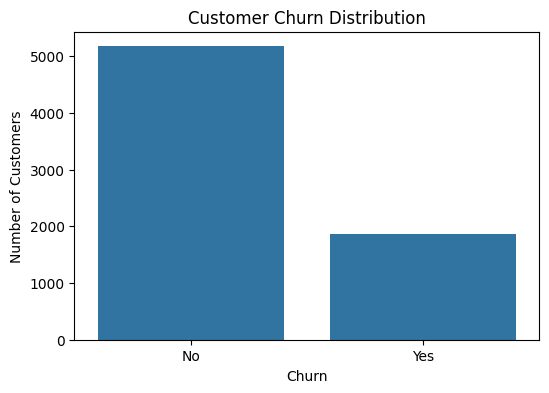

In [15]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Observation

Most customers did not churn, while 26.54% of customers churned. This shows that the target variable is imbalanced, with the `No` class representing about 73.46% of the data.

Therefore, accuracy alone may not be enough to evaluate our models. We should also consider metrics such as precision, recall, F1-score, and ROC-AUC.

## Numerical Features vs Churn

Next, we will examine the numerical features and compare their distributions between customers who churned and those who stayed.

### Tenure vs Churn

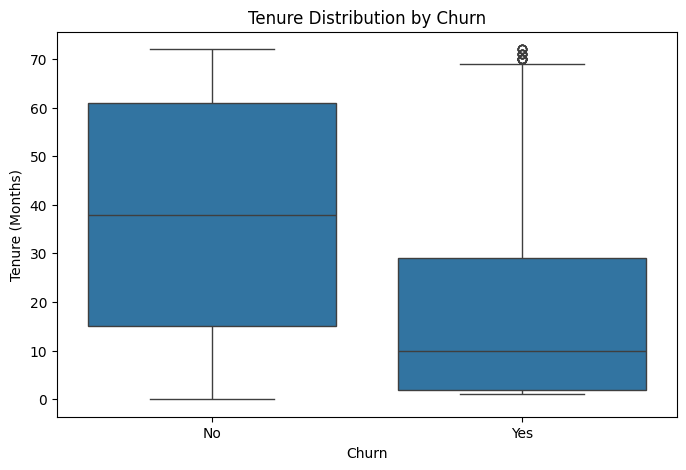

In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

### Observation

Customers who churned generally have a much shorter tenure than customers who stayed. The median tenure of churned customers is around 10 months, compared with around 38 months for customers who stayed.

This suggests that newer customers are more likely to churn, making `tenure` an important feature for predicting churn.

### Monthly Charges vs Churn

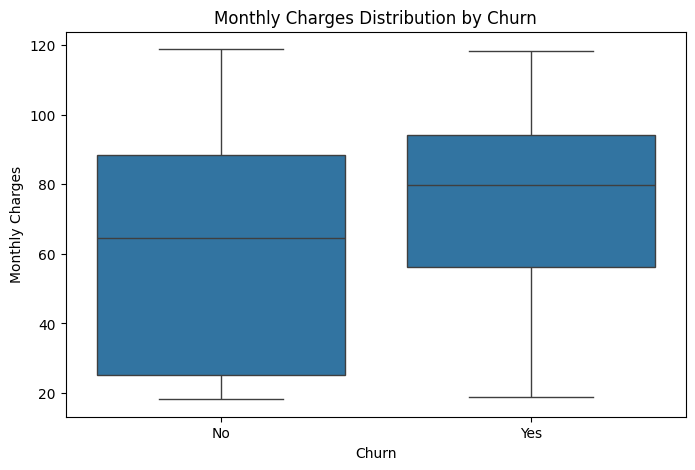

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

### Observation

Customers who churned generally have higher monthly charges than customers who stayed. The median monthly charge is around 80 for churned customers compared with around 65 for customers who stayed.

This suggests that `MonthlyCharges` may be an important feature for predicting customer churn.

## Categorical Features vs Churn

### Contract Type vs Churn

Let's examine whether customer churn differs across different contract types.

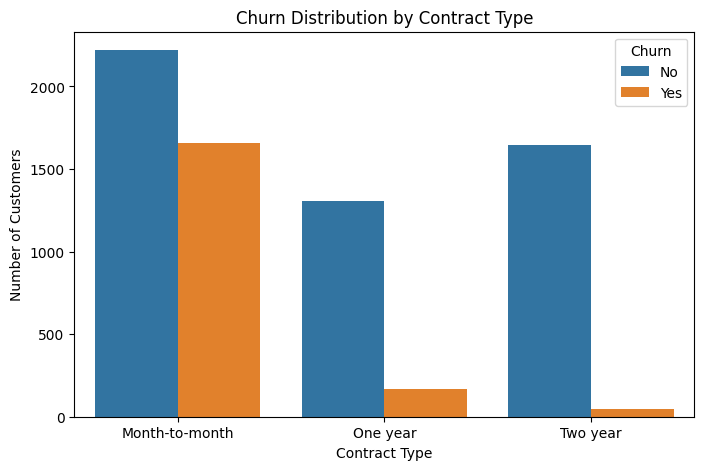

In [18]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Churn Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

In [19]:
contract_churn_rate = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn_rate

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


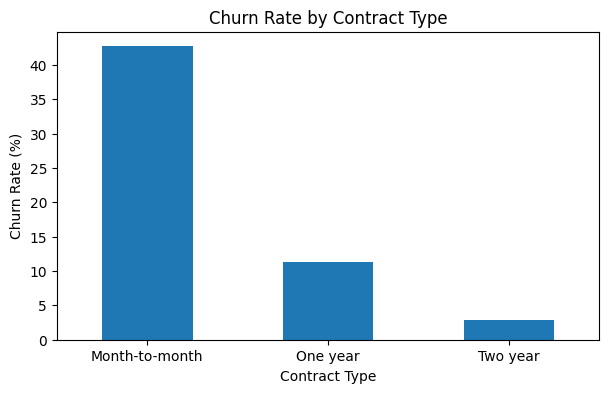

In [20]:
contract_churn_rate["Yes"].plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

### Observation

Contract type shows a strong relationship with customer churn. Month-to-month customers have the highest churn rate at around 43%, while one-year and two-year contract customers have much lower churn rates.

This suggests that customers with longer-term contracts are more likely to stay with the company, making `Contract` an important feature for churn prediction.

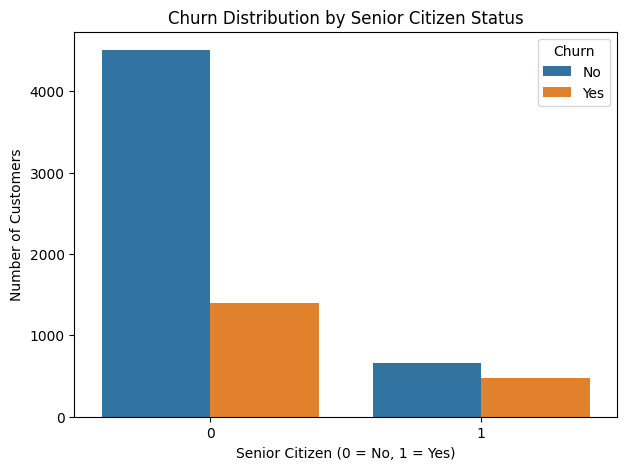

In [21]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)

plt.title("Churn Distribution by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

In [22]:
senior_churn_rate = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

senior_churn_rate

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


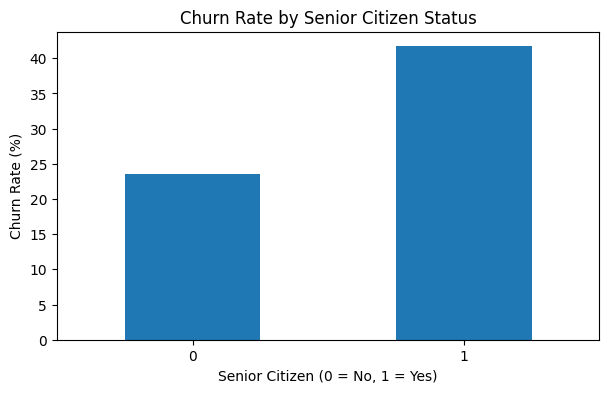

In [23]:
senior_churn_rate["Yes"].plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

### Observation

Senior citizens have a higher churn rate than non-senior customers. The churn rate is around 42% for senior citizens compared with around 24% for non-senior customers.

This suggests that `SeniorCitizen` may be a useful feature for predicting customer churn.

### Other Categorical Features

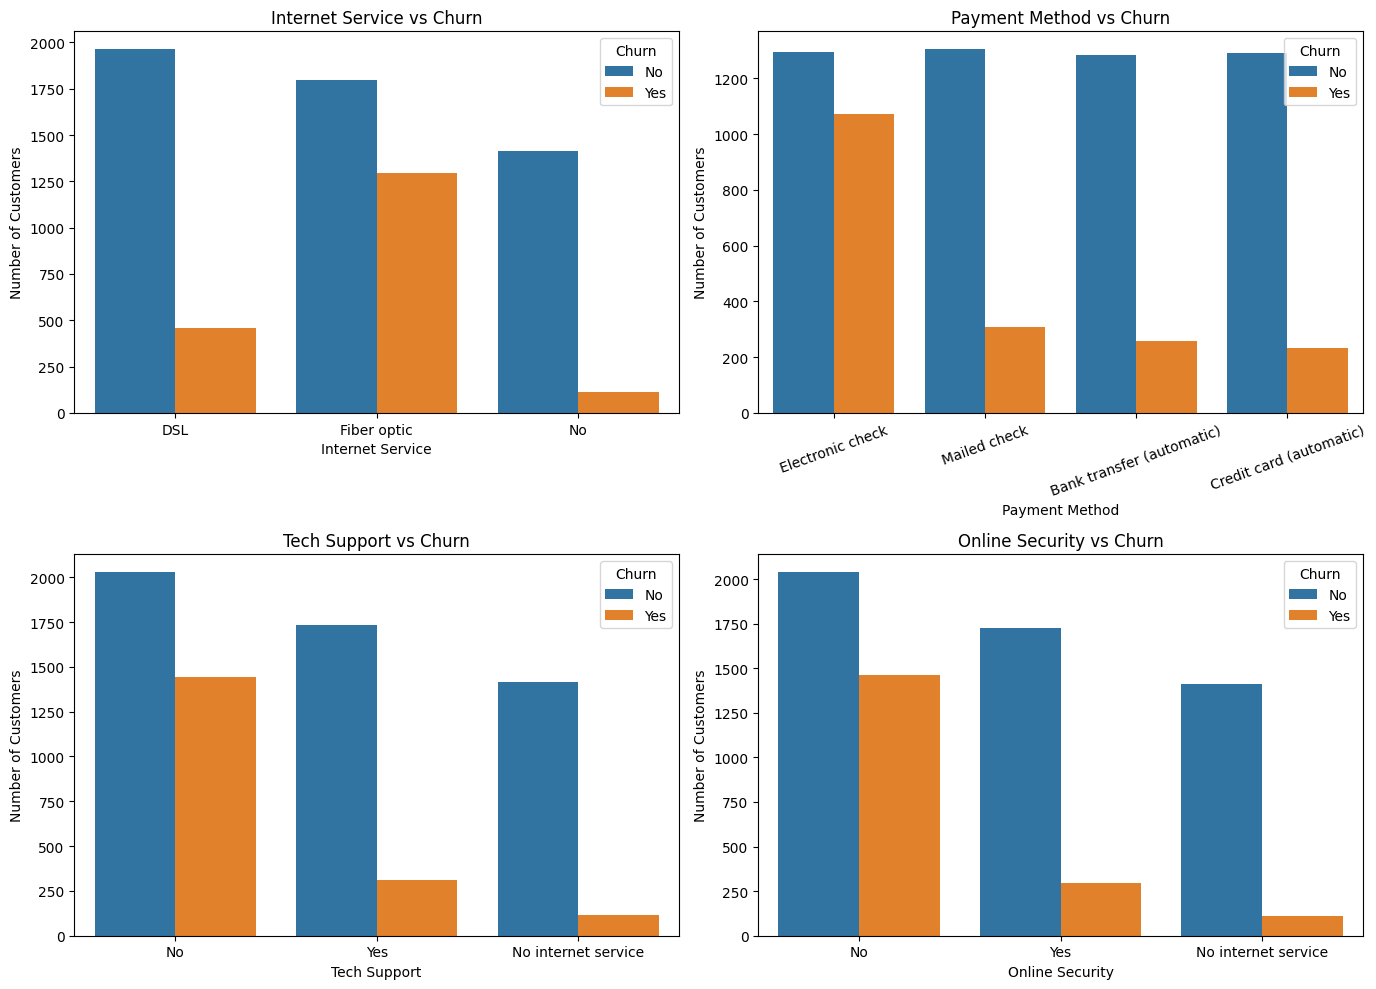

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x="InternetService", hue="Churn", ax=axes[0, 0])
axes[0, 0].set_title("Internet Service vs Churn")
axes[0, 0].set_xlabel("Internet Service")
axes[0, 0].set_ylabel("Number of Customers")

sns.countplot(data=df, x="PaymentMethod", hue="Churn", ax=axes[0, 1])
axes[0, 1].set_title("Payment Method vs Churn")
axes[0, 1].set_xlabel("Payment Method")
axes[0, 1].set_ylabel("Number of Customers")
axes[0, 1].tick_params(axis="x", rotation=20)

sns.countplot(data=df, x="TechSupport", hue="Churn", ax=axes[1, 0])
axes[1, 0].set_title("Tech Support vs Churn")
axes[1, 0].set_xlabel("Tech Support")
axes[1, 0].set_ylabel("Number of Customers")

sns.countplot(data=df, x="OnlineSecurity", hue="Churn", ax=axes[1, 1])
axes[1, 1].set_title("Online Security vs Churn")
axes[1, 1].set_xlabel("Online Security")
axes[1, 1].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [25]:
features = [
    "Contract",
    "SeniorCitizen",
    "InternetService",
    "PaymentMethod",
    "TechSupport",
    "OnlineSecurity"
]

for feature in features:
    print(f"\n{feature}")
    print(
        pd.crosstab(
            df[feature],
            df["Churn"],
            normalize="index"
        )["Yes"].sort_values(ascending=False)
    )


Contract
Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Yes, dtype: float64

SeniorCitizen
SeniorCitizen
1    0.416813
0    0.236062
Name: Yes, dtype: float64

InternetService
InternetService
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: Yes, dtype: float64

PaymentMethod
PaymentMethod
Electronic check             0.452854
Mailed check                 0.191067
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Name: Yes, dtype: float64

TechSupport
TechSupport
No                     0.416355
Yes                    0.151663
No internet service    0.074050
Name: Yes, dtype: float64

OnlineSecurity
OnlineSecurity
No                     0.417667
Yes                    0.146112
No internet service    0.074050
Name: Yes, dtype: float64


### Categorical Feature Insights

The churn rates show strong differences across several categorical features. Month-to-month contracts, electronic-check payments, fiber-optic internet service, senior-citizen status, and the absence of technical support or online security are associated with higher churn rates.

In contrast, customers with longer-term contracts, automatic payment methods, technical support, or online security generally have lower churn rates. These features may therefore provide useful information for predicting customer churn.

### Correlation Between Numerical Features

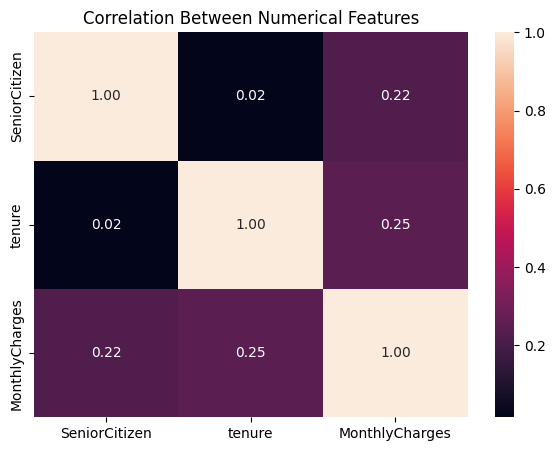

In [26]:
numerical_features = ["SeniorCitizen", "tenure", "MonthlyCharges"]

plt.figure(figsize=(7, 5))

sns.heatmap(
    df[numerical_features].corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Numerical Features")
plt.show()

### Observation

The numerical features show only weak correlations with each other. The highest correlation is between `tenure` and `MonthlyCharges` at approximately 0.25, which is still relatively weak.

Therefore, there is no strong multicollinearity among these numerical features based on this correlation analysis.

## Data Cleaning

Before building the model, we need to ensure that the dataset is clean and that each feature has the correct data type. We will check for missing values, invalid values, duplicates, and unnecessary columns.

In [27]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### Checking Missing and Invalid Values

Although the dataset contains no standard missing values (`NaN`), we should also check for blank strings and other invalid values, especially in `TotalCharges`.

In [28]:
df["TotalCharges"].str.strip().eq("").sum()

np.int64(11)

In [29]:
df["TotalCharges"].str.strip().eq(" ").sum()

np.int64(0)

In [30]:
df[df["TotalCharges"].str.strip() == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [31]:
df[df["TotalCharges"].str.strip() == ""][[
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Churn"
]]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,,No
753,0,20.25,,No
936,0,80.85,,No
1082,0,25.75,,No
1340,0,56.05,,No
3331,0,19.85,,No
3826,0,25.35,,No
4380,0,20.00,,No
5218,0,19.70,,No
6670,0,73.35,,No


### Handling Missing Values in `TotalCharges`

The `TotalCharges` column contains 11 blank values. After inspecting these records, we found that all of them have a tenure of 0 months and have not churned.

Since these customers are new and have no accumulated charges, the blank values can reasonably be treated as 0.

In [32]:
df["TotalCharges"] = df["TotalCharges"].str.strip()

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [33]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [34]:
df["TotalCharges"].dtype

dtype('float64')

In [35]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


### Checking for Duplicate Records

In [36]:
df.duplicated().sum()

np.int64(0)

### Observation

The dataset contains no duplicate records, so no rows need to be removed based on duplication.

### Handling the Customer ID

The `customerID` column is a unique identifier for each customer. It does not contain meaningful information that should be used to predict churn, so it will be removed before model training.

In [37]:
df["customerID"].nunique()

7043

In [38]:
df = df.drop("customerID", axis=1)

In [39]:
df.shape

(7043, 20)

In [40]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


### Skewness Analysis



In [41]:
numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

df[numerical_features].skew()

,0
tenure,0.239540
MonthlyCharges,-0.220524
TotalCharges,0.963235


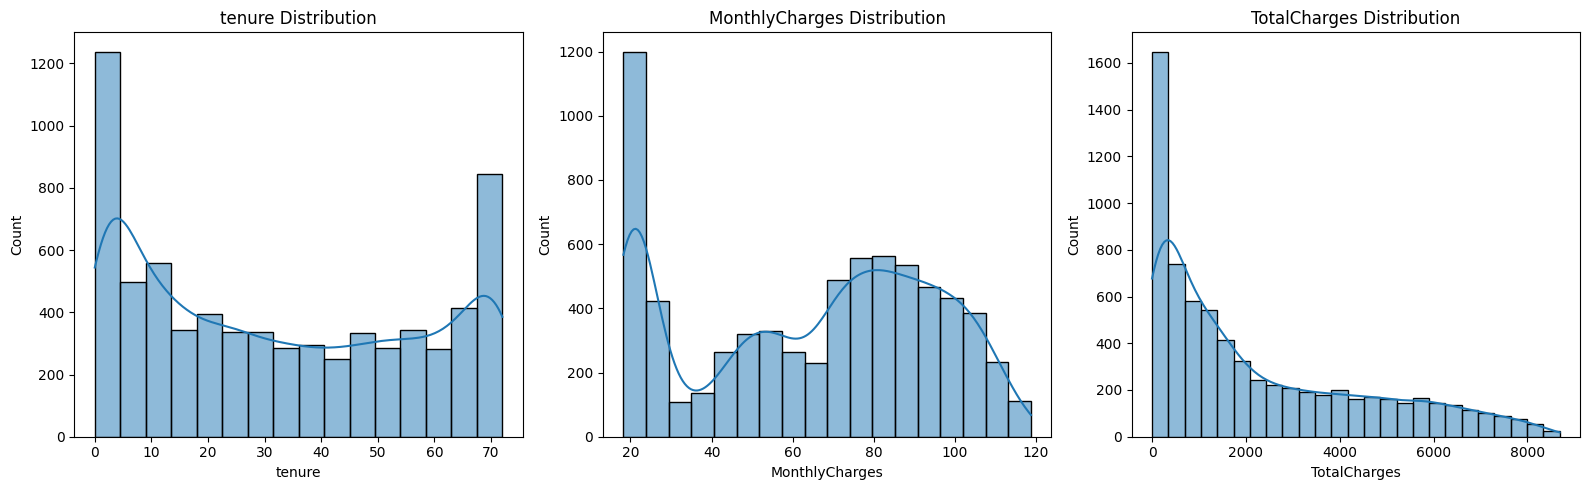

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feature in zip(axes, numerical_features):
    sns.histplot(data=df, x=feature, kde=True, ax=ax)
    ax.set_title(f"{feature} Distribution")

plt.tight_layout()
plt.show()

### Checking Outliers

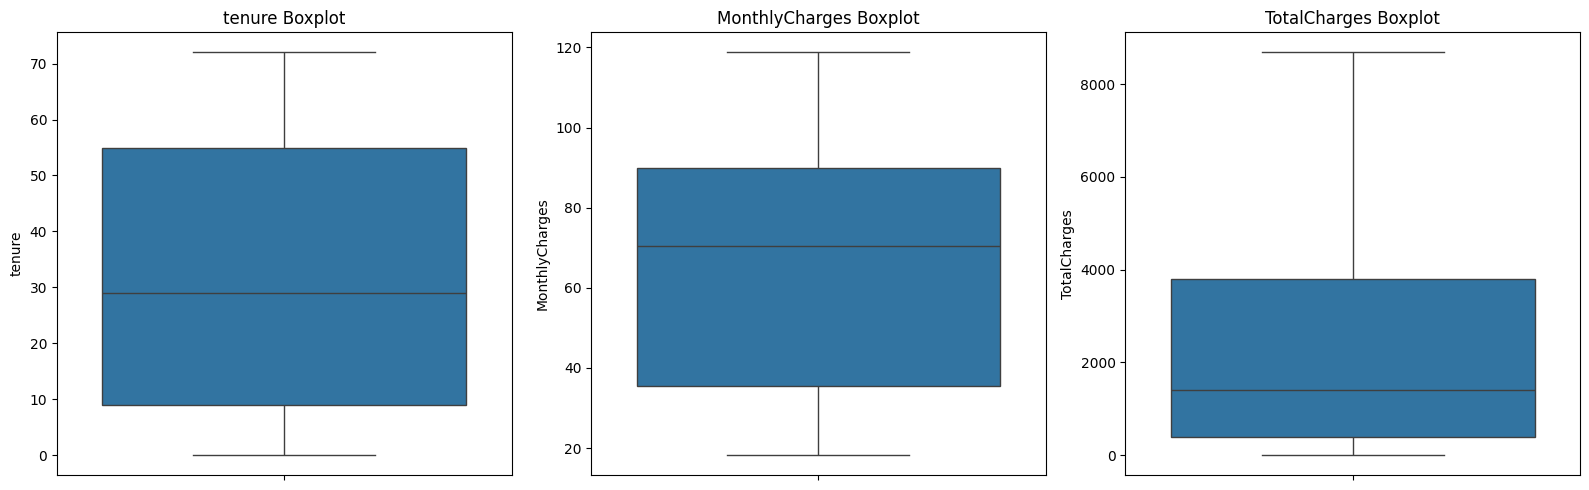

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feature in zip(axes, numerical_features):
    sns.boxplot(data=df, y=feature, ax=ax)
    ax.set_title(f"{feature} Boxplot")

plt.tight_layout()
plt.show()

### Observation

The numerical features do not show significant problematic outliers. Although `TotalCharges` is moderately right-skewed, its higher values are reasonable because customers with longer tenures naturally accumulate higher total charges.

Therefore, we will keep the numerical features in their original form without removing outliers or applying a transformation.

## Train-Test Split

In [44]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [45]:
y = y.map({"No": 0, "Yes": 1})

In [46]:
y.value_counts()

,count
Churn,
0,5174
1,1869


In [47]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

In [48]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 19)
(1409, 19)
(5634,)
(1409,)


## Preprocessing

In [49]:
numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

binary_features = [
    "SeniorCitizen"
]

categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [50]:
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

bin_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer(transformers=[
    ("numerical", num_pipeline, numerical_features),
    ("binary", bin_pipeline, binary_features),
    ("categorical", cat_pipeline, categorical_features)
])

preprocessor

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges']),
                                ('binary',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['SeniorCitizen']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])

## Model Training

We will start with Logistic Regression as our baseline model for predicting customer churn.

The preprocessing steps and the model are combined into a single pipeline so that the same transformations are consistently applied during training and prediction.

Since the churn classes are imbalanced, we will use class weights to give more importance to the minority churn class.

## Logistic Regression

In [51]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('binary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['SeniorCitizen']),
                                                 ('categorical',
                                                  Pipeline(steps=[('impute...
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [52]:
y_pred = logistic_pipeline.predict(X_test)

In [53]:
train_pred = logistic_pipeline.predict(X_train)

In [54]:
print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Testing Accuracy :", accuracy_score(y_test, y_pred))

Training Accuracy: 0.7532836350727724
Testing Accuracy : 0.7381121362668559


In [55]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [56]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[747 288]
 [ 81 293]]


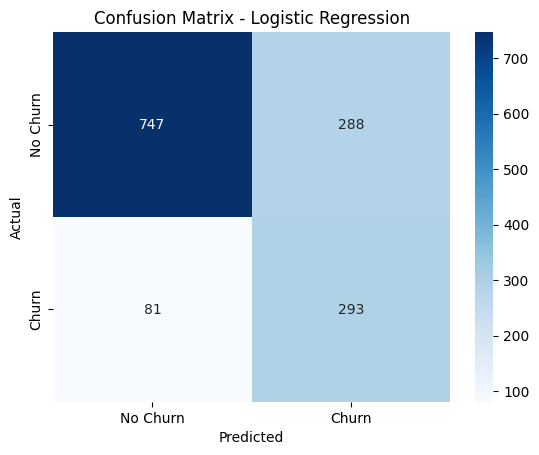

In [57]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [58]:
y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8417318969748638


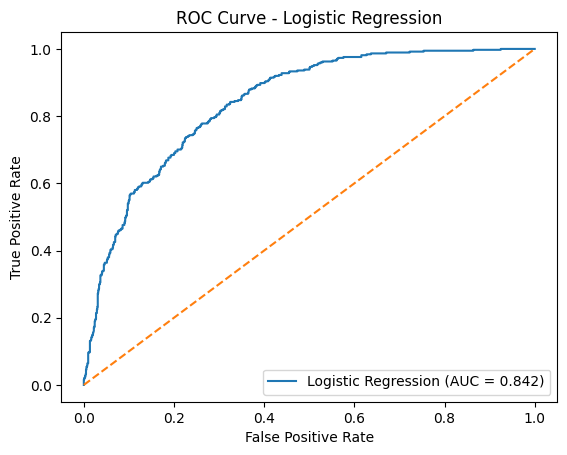

In [59]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

## Logistic Regression — Baseline Results

Logistic Regression was used as our baseline model for predicting customer churn. The model was evaluated using multiple metrics because accuracy alone is not sufficient for our imbalanced dataset.

The model achieved a testing accuracy of **73.81%** and a training accuracy of **75.33%**, with only a small gap between them, suggesting no major overfitting.

For the **Churn** class, the model achieved **50% precision**, **78% recall**, and **61% F1-score**. The higher recall is useful for our business problem because identifying customers who are likely to churn is important.

The model achieved a **ROC-AUC score of 0.842**, indicating good ability to distinguish between customers who churn and those who do not.

Overall, Logistic Regression provides a useful baseline that we can compare with other classification models.

## Random Forest

In [60]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])
random_forest_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('binary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['SeniorCitizen']),
                                                 ('categorical',
                                                  Pipeline(steps=[('impute...
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', n_jobs=-1,
                                        random_state=42))])

In [61]:
rf_pred = random_forest_pipeline.predict(X_test)
rf_pred_train = random_forest_pipeline.predict(X_train)

In [62]:
print("Training Accuracy:", accuracy_score(y_train, rf_pred_train))
print("Testing Accuracy :", accuracy_score(y_test, rf_pred))

Training Accuracy: 0.9980475683351083
Testing Accuracy : 0.7963094393186657


In [63]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.65      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



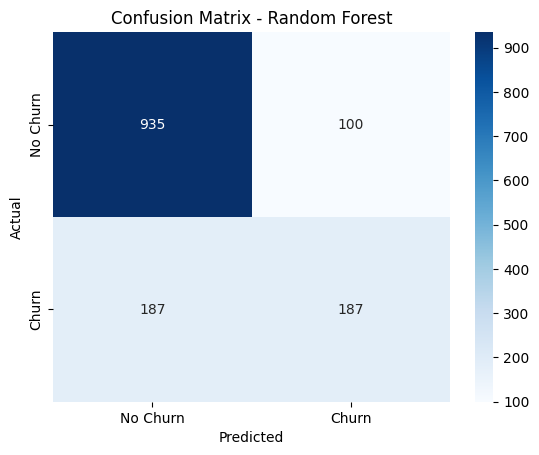

In [64]:
rf_cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

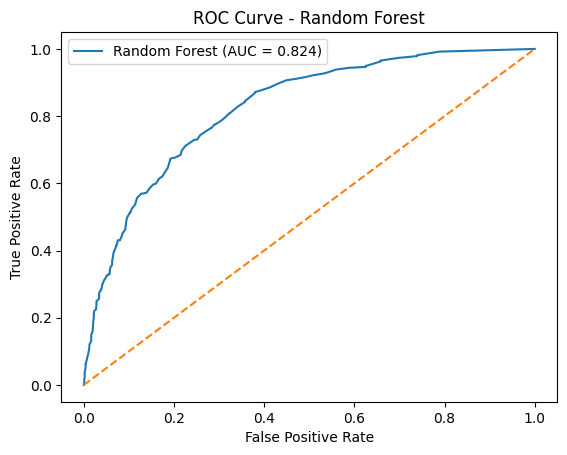

Random Forest ROC-AUC: 0.8237696659691544


In [65]:
rf_prob = random_forest_pipeline.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, rf_prob)
rf_auc = roc_auc_score(y_test, rf_prob)

plt.plot(fpr, tpr, label=f"Random Forest (AUC = {rf_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

print("Random Forest ROC-AUC:", rf_auc)

## Random Forest — Baseline Results

Random Forest achieved a testing accuracy of **79.63%**, which was higher than Logistic Regression. However, the training accuracy was **99.80%**, indicating significant overfitting.

For the **Churn** class, Random Forest achieved **65% precision**, **50% recall**, and **57% F1-score**. Although it produced fewer false positives than Logistic Regression, it missed many actual churners.

The model achieved a **ROC-AUC score of 0.824**, which was slightly lower than the Logistic Regression baseline of **0.842**.

Therefore, the baseline Random Forest did not outperform Logistic Regression for our churn prediction objective. We will later consider hyperparameter tuning to reduce overfitting and improve its performance.

## XGBoost

In [66]:
scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)
print(scale_pos_weight)

2.768561872909699


In [67]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('binary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['SeniorCitizen']),
                                                 ('categorical',
                                                  Pipeline(steps=[('impute...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [68]:
xgb_pred = xgb_pipeline.predict(X_test)
xgb_pred_train = xgb_pipeline.predict(X_train)

In [69]:
print("Training Accuracy:", accuracy_score(y_train, xgb_pred_train))
print("Testing Accuracy :", accuracy_score(y_test, xgb_pred))

Training Accuracy: 0.8919062832800851
Testing Accuracy : 0.7622427253371186


In [70]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1035
           1       0.54      0.72      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409



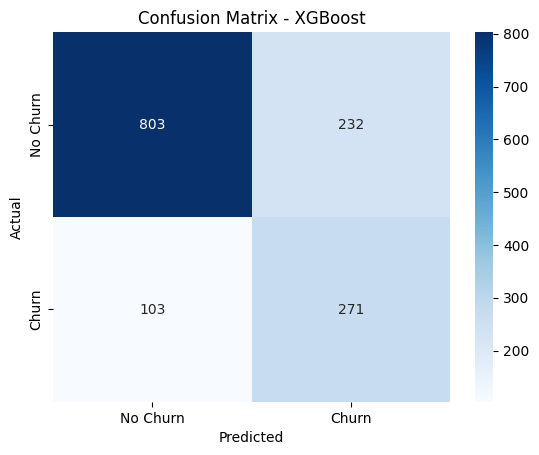

In [71]:
xgb_cm = confusion_matrix(y_test, xgb_pred)

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

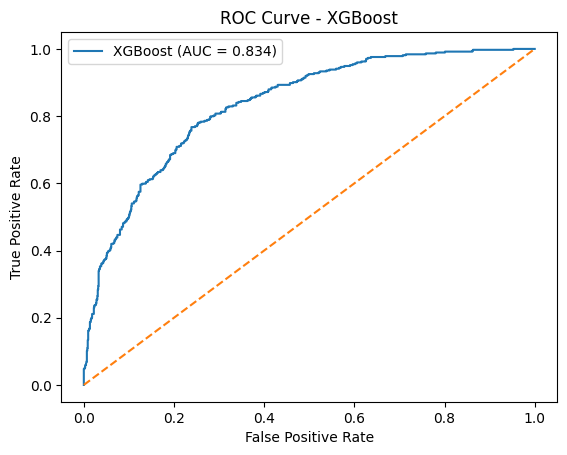

XGBoost ROC-AUC: 0.8339339688444548


In [72]:
xgb_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, xgb_prob)
xgb_auc = roc_auc_score(y_test, xgb_prob)

plt.plot(fpr, tpr, label=f"XGBoost (AUC = {xgb_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

print("XGBoost ROC-AUC:", xgb_auc)

## Baseline Model Comparison

We trained and evaluated three classification models: Logistic Regression, Random Forest, and XGBoost.

| Metric | Logistic Regression | Random Forest | XGBoost |
|---|---:|---:|---:|
| Training Accuracy | 75.33% | 99.80% | 89.19% |
| Testing Accuracy | 73.81% | 79.63% | 76.22% |
| Churn Precision | 50% | 65% | 54% |
| Churn Recall | 78% | 50% | 72% |
| Churn F1-score | 61% | 57% | 62% |
| ROC-AUC | 0.842 | 0.824 | 0.834 |

### Observations

- **Logistic Regression** achieved the highest Churn Recall (**78%**) and ROC-AUC (**0.842**) and showed very little overfitting.
- **Random Forest** achieved the highest Testing Accuracy (**79.63%**) and Churn Precision (**65%**), but showed significant overfitting with a Training Accuracy of **99.80%**.
- **XGBoost** achieved the highest Churn F1-score (**62%**) and a good Churn Recall (**72%**), but showed some overfitting.
- Accuracy alone is not used to select the final model because identifying customers who are likely to churn is an important objective.

### Next Step

The baseline models will now be improved using **Cross-Validation and Hyperparameter Tuning**.

The test set will remain untouched during tuning and will only be used for the final evaluation of the selected model.

## Random Forest — Hyperparameter Tuning

The baseline Random Forest showed significant overfitting, with a training accuracy of **99.80%** compared to a testing accuracy of **79.63%**.

To improve generalization, we will tune the Random Forest hyperparameters using **RandomizedSearchCV with 5-fold Cross-Validation**.

In [73]:
param_dist = {
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", "log2", None]
}

In [74]:
from sklearn.model_selection import RandomizedSearchCV

rf_random_search = RandomizedSearchCV(
    estimator=random_forest_pipeline,
    param_distributions=param_dist,
    n_iter=15,
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random_search.fit(X_train, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('numerical',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['tenure',
                                                                                'MonthlyCharges',
                                                                                'TotalCharges']),
                                                                              ('binary',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent'))]),
                                                                               ['SeniorCitizen']),
                                                                              ('cat...
                                              RandomForestClassifier(class_weight='balanced',
                                                                     n_jobs=-1,
                                                                     random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 5, 10, 15,
                                                             20],
                                        'model__max_features': ['sqrt', 'log2',
                                                                None],
                                        'model__min_samples_leaf': [1, 2, 4, 8],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 150, 200]},
                   random_state=42, scoring='roc_auc', verbose=1)

In [75]:
print("Best Parameters:")
print(rf_random_search.best_params_)

print("\nBest CV ROC-AUC:")
print(rf_random_search.best_score_)

Best Parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': 10}

Best CV ROC-AUC:
0.8461163882880841


In [76]:
rf_best = rf_random_search.best_estimator_
rf_tuned_pred = rf_best.predict(X_test)

In [77]:
rf_tuned_train_acc = rf_best.score(X_train, y_train)
rf_tuned_test_acc = rf_best.score(X_test, y_test)

print("Tuned Random Forest Training Accuracy:", rf_tuned_train_acc)
print("Tuned Random Forest Testing Accuracy:", rf_tuned_test_acc)

Tuned Random Forest Training Accuracy: 0.8209087681931132
Tuned Random Forest Testing Accuracy: 0.7672107877927609


In [78]:
print(classification_report(y_test, rf_tuned_pred))

              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1035
           1       0.54      0.77      0.64       374

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.77      0.78      1409



In [79]:
rf_tuned_prob = rf_best.predict_proba(X_test)[:, 1]

rf_tuned_auc = roc_auc_score(y_test, rf_tuned_prob)

print("Tuned Random Forest ROC-AUC:", rf_tuned_auc)

Tuned Random Forest ROC-AUC: 0.8434666356661242


## Tuned Random Forest — Results

RandomizedSearchCV with 5-fold Cross-Validation was used to tune the Random Forest.

The best parameters were:

- `n_estimators = 200`
- `max_depth = 10`
- `min_samples_split = 2`
- `min_samples_leaf = 4`
- `max_features = log2`

The tuned model significantly reduced overfitting. The training-testing accuracy gap decreased from **20.17%** in the baseline model to **5.37%**.

Although testing accuracy decreased from **79.63% to 76.72%**, the model improved substantially in churn detection:

- Churn Recall: **50% → 77%**
- Churn F1-score: **57% → 64%**
- ROC-AUC: **0.824 → 0.843**

The tuned Random Forest therefore provides a much better balance between generalization and churn detection than the baseline Random Forest.

## XGBoost — Hyperparameter Tuning

The baseline XGBoost model achieved a testing accuracy of **76.22%**, with a Churn Recall of **72%**, Churn F1-score of **62%**, and ROC-AUC of **0.834**.

The model also showed some overfitting, with a training accuracy of **89.19%** compared to a testing accuracy of **76.22%**.

To improve generalization and performance, we will use **RandomizedSearchCV with 5-fold Cross-Validation**.

The following hyperparameters will be tuned:

- `n_estimators` — number of boosting trees
- `learning_rate` — contribution of each tree
- `max_depth` — complexity of each tree
- `min_child_weight` — controls the minimum amount of data needed for a split
- `subsample` — fraction of training samples used for each tree
- `colsample_bytree` — fraction of features used for each tree

In [80]:
xgb_param_dist = {
    "model__n_estimators": [100, 150, 200],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__min_child_weight": [1, 3, 5],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__scale_pos_weight": [1, 2, 2.5, 2.77, 3, 3.5]
}

In [81]:
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=15,
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_random_search.fit(X_train, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('numerical',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['tenure',
                                                                                'MonthlyCharges',
                                                                                'TotalCharges']),
                                                                              ('binary',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent'))]),
                                                                               ['SeniorCitizen']),
                                                                              ('cat...
                                                            num_parallel_tree=None, ...))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.8, 1.0],
                                        'model__learning_rate': [0.01, 0.05,
                                                                 0.1],
                                        'model__max_depth': [3, 5, 7],
                                        'model__min_child_weight': [1, 3, 5],
                                        'model__n_estimators': [100, 150, 200],
                                        'model__scale_pos_weight': [1, 2, 2.5,
                                                                    2.77, 3,
                                                                    3.5],
                                        'model__subsample': [0.8, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=1)

In [82]:
print("Best Parameters:")
print(xgb_random_search.best_params_)

print("\nBest CV ROC-AUC:")
print(xgb_random_search.best_score_)

Best Parameters:
{'model__subsample': 0.8, 'model__scale_pos_weight': 2.77, 'model__n_estimators': 100, 'model__min_child_weight': 1, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}

Best CV ROC-AUC:
0.8476940876882131


In [83]:
xgb_best = xgb_random_search.best_estimator_
xgb_tuned_pred = xgb_best.predict(X_test)

In [84]:
print("Tuned XGBoost Training Accuracy:", xgb_best.score(X_train, y_train))
print("Tuned XGBoost Testing Accuracy:", xgb_best.score(X_test, y_test))

Tuned XGBoost Training Accuracy: 0.759318423855165
Tuned XGBoost Testing Accuracy: 0.7409510290986515


In [85]:
print(classification_report(y_test, xgb_tuned_pred))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.81      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.81      0.74      0.76      1409



In [86]:
xgb_tuned_prob = xgb_best.predict_proba(X_test)[:, 1]

xgb_tuned_auc = roc_auc_score(y_test, xgb_tuned_prob)

print("Tuned XGBoost ROC-AUC:", xgb_tuned_auc)

Tuned XGBoost ROC-AUC: 0.84632126895554


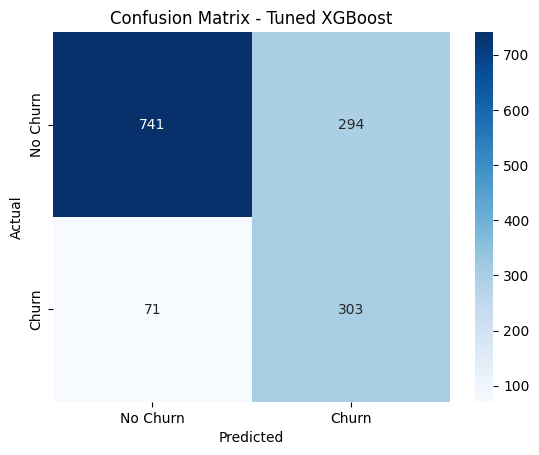

In [87]:
xgb_tuned_cm = confusion_matrix(y_test, xgb_tuned_pred)

sns.heatmap(
    xgb_tuned_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned XGBoost")
plt.show()

In [88]:
xgb_model = xgb_best.named_steps["model"]
feature_importances = xgb_model.feature_importances_

In [89]:
feature_names = xgb_best.named_steps["preprocessor"].get_feature_names_out()

In [90]:
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df.head(15)

,Feature,Importance
25,categorical__Contract_Two year,0.226501
12,categorical__OnlineSecurity_No internet service,0.124519
24,categorical__Contract_One year,0.124327
10,categorical__InternetService_Fiber optic,0.112640
0,numerical__tenure,0.054561
11,categorical__InternetService_No,0.051070
28,categorical__PaymentMethod_Electronic check,0.050675
26,categorical__PaperlessBilling_Yes,0.027964
23,categorical__StreamingMovies_Yes,0.025897
13,categorical__OnlineSecurity_Yes,0.024578


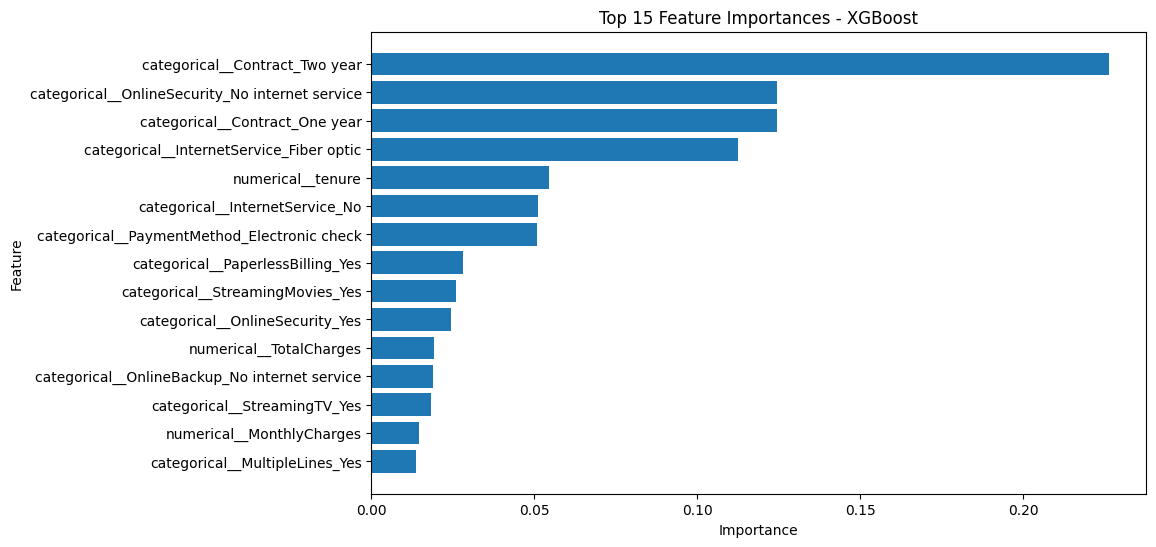

In [91]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - XGBoost")
plt.show()

## Final Model — Tuned XGBoost

After comparing Logistic Regression, Random Forest, and XGBoost, the **class-weighted tuned XGBoost** was selected as the final model.

The final model uses:

- `n_estimators = 100`
- `learning_rate = 0.05`
- `max_depth = 3`
- `min_child_weight = 1`
- `subsample = 0.8`
- `colsample_bytree = 0.8`
- `scale_pos_weight = 2.77`

### Final Test Performance

- **Accuracy:** 74.10%
- **Churn Precision:** 51%
- **Churn Recall:** 81%
- **Churn F1-score:** 62%
- **ROC-AUC:** 0.846

The model achieved a training accuracy of **75.93%** and testing accuracy of **74.10%**, giving a train-test gap of only **1.84%**, indicating relatively low overfitting.

The model was selected primarily because identifying potential churners is the main objective. It correctly identified **303 out of 374 actual churners**, achieving approximately **81% recall**.

Feature importance analysis showed that features related to **Contract, OnlineSecurity, InternetService, Tenure, and PaymentMethod** were among the most influential features in the final XGBoost model.

## Save the Model and Preprocessor

The final XGBoost model is stored inside the trained `xgb_best` pipeline along with the fitted preprocessing pipeline.

For deployment, we save them separately:

* `preprocessor.pkl` → contains the fitted `ColumnTransformer` used during training.
* `xgb_model.json` → contains the trained XGBoost model using XGBoost's native model format.

This avoids relying on Python `joblib` serialization for the XGBoost model itself and allows the preprocessing and model to be loaded separately in the FastAPI application.





In [103]:
import joblib

preprocessor = xgb_best.named_steps["preprocessor"]
xgb_model = xgb_best.named_steps["model"]

In [104]:
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

In [105]:
xgb_model.save_model("xgb_model.json")

## Manual Model Testing


In [106]:
loaded_preprocessor = joblib.load("preprocessor.pkl")

In [108]:
loaded_xgb = XGBClassifier()
loaded_xgb.load_model("xgb_model.json")

In [109]:
manual_data = pd.DataFrame([
    {
        "gender": "Female",
        "SeniorCitizen": 0,
        "Partner": "No",
        "Dependents": "No",
        "tenure": 3,
        "PhoneService": "Yes",
        "MultipleLines": "No",
        "InternetService": "Fiber optic",
        "OnlineSecurity": "No",
        "OnlineBackup": "No",
        "DeviceProtection": "No",
        "TechSupport": "No",
        "StreamingTV": "Yes",
        "StreamingMovies": "Yes",
        "Contract": "Month-to-month",
        "PaperlessBilling": "Yes",
        "PaymentMethod": "Electronic check",
        "MonthlyCharges": 85.5,
        "TotalCharges": 256.5
    },
    {
        "gender": "Male",
        "SeniorCitizen": 0,
        "Partner": "Yes",
        "Dependents": "Yes",
        "tenure": 60,
        "PhoneService": "Yes",
        "MultipleLines": "Yes",
        "InternetService": "DSL",
        "OnlineSecurity": "Yes",
        "OnlineBackup": "Yes",
        "DeviceProtection": "Yes",
        "TechSupport": "Yes",
        "StreamingTV": "No",
        "StreamingMovies": "No",
        "Contract": "Two year",
        "PaperlessBilling": "No",
        "PaymentMethod": "Bank transfer (automatic)",
        "MonthlyCharges": 55.0,
        "TotalCharges": 3300.0
    },
    {
        "gender": "Female",
        "SeniorCitizen": 1,
        "Partner": "No",
        "Dependents": "No",
        "tenure": 12,
        "PhoneService": "Yes",
        "MultipleLines": "No",
        "InternetService": "Fiber optic",
        "OnlineSecurity": "No",
        "OnlineBackup": "Yes",
        "DeviceProtection": "No",
        "TechSupport": "No",
        "StreamingTV": "Yes",
        "StreamingMovies": "No",
        "Contract": "One year",
        "PaperlessBilling": "Yes",
        "PaymentMethod": "Mailed check",
        "MonthlyCharges": 75.0,
        "TotalCharges": 900.0
    }
])

In [110]:
manual_data_transformed = loaded_preprocessor.transform(manual_data)
manual_pred = loaded_xgb.predict(manual_data_transformed)
manual_prob = loaded_xgb.predict_proba(manual_data_transformed)[:, 1]

In [111]:
for i in range(len(manual_data)):
    print(f"Customer {i+1}")
    print("Prediction:", "Churn" if manual_pred[i] == 1 else "No Churn")
    print(f"Churn Probability: {manual_prob[i]:.2%}")
    print()

Customer 1
Prediction: Churn
Churn Probability: 86.85%

Customer 2
Prediction: No Churn
Churn Probability: 4.17%

Customer 3
Prediction: Churn
Churn Probability: 52.96%



## Verify Saved Model Predictions

The predictions from the separately saved preprocessor and XGBoost model are compared with the predictions from the original `xgb_best` pipeline.

The predictions should be identical because both use the same fitted preprocessing and trained model.


In [112]:
# Predictions from the original pipeline
original_pred = xgb_best.predict(manual_data)

# Compare with predictions from the saved components
print(
    "Predictions identical:",
    (original_pred == manual_pred).all()
)

Predictions identical: True


## Final Deployment Verification

The fitted preprocessor and XGBoost model were saved separately and successfully loaded again.

Manual customer data was passed through the saved preprocessing pipeline and then used by the saved XGBoost model to generate churn predictions and probabilities.

The predictions from the saved components were also compared with the original `xgb_best` pipeline to verify that the model behavior remained unchanged.
